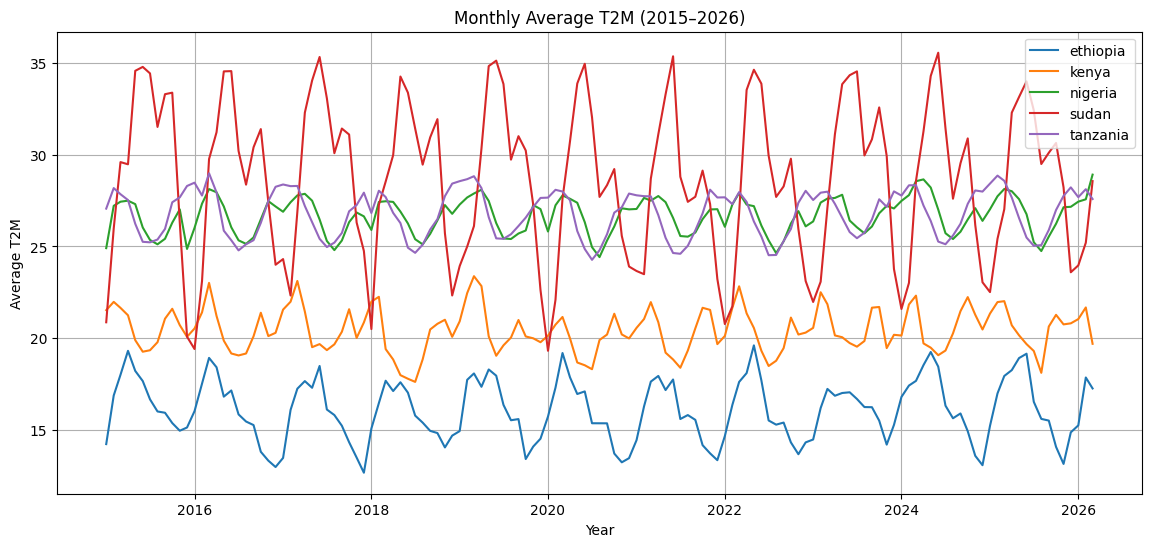

,COUNTRY,mean,median,std
0,Ethiopia,16.068500,16.04,1.898050
1,Kenya,20.427245,20.36,1.419770
2,Nigeria,26.656928,26.82,1.123335
3,Sudan,28.759007,29.16,4.681305
4,Tanzania,26.802422,26.99,1.325388


In [35]:
#Task_3
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd

# Load cleaned datasets
ethiopia_df = pd.read_csv("../data/ethiopia_clean.csv")
kenya_df = pd.read_csv("../data/kenya_clean.csv")
nigeria_df = pd.read_csv("../data/nigeria_clean.csv")
sudan_df = pd.read_csv("../data/sudan_clean.csv")
tanzania_df = pd.read_csv("../data/tanzania_clean.csv")

# Add country labels
ethiopia_df["COUNTRY"] = "Ethiopia"
kenya_df["COUNTRY"] = "Kenya"
nigeria_df["COUNTRY"] = "Nigeria"
sudan_df["COUNTRY"] = "Sudan"
tanzania_df["COUNTRY"] = "Tanzania"

# Concatenate into one dataframe
final_df = pd.concat([
    ethiopia_df,
    kenya_df,
    nigeria_df,
    sudan_df,
    tanzania_df
], axis=0).reset_index(drop=True)

# Preview
final_df.head()

# Make sure date column is datetime
final_df["DATE"] = pd.to_datetime(final_df["DATE"])

# Keep years 2015–2026
final_df = final_df[(final_df["DATE"].dt.year >= 2015) & (final_df["DATE"].dt.year <= 2026)]

# Create year-month column
final_df["year_month"] = final_df["DATE"].dt.to_period("M")

# Calculate monthly average T2M per country
monthly_avg = (
    final_df.groupby(["year_month", "Country"])["T2M"]
      .mean()
      .reset_index()
)

# Convert period to timestamp for plotting
monthly_avg["year_month"] = monthly_avg["year_month"].dt.to_timestamp()

# Plot
plt.figure(figsize=(14, 6))

for country in monthly_avg["Country"].unique():
    country_data = monthly_avg[monthly_avg["Country"] == country]

    plt.plot(
        country_data["year_month"],
        country_data["T2M"],
        label=country
    )

# Formatting
plt.title("Monthly Average T2M (2015–2026)")
plt.xlabel("Year")
plt.ylabel("Average T2M")
plt.legend()
plt.grid(True)

plt.show()

summary_table = (
    final_df.groupby("COUNTRY")["T2M"]
    .agg(["mean", "median", "std"])
    .reset_index()
)

summary_table

<Figure size 1000x600 with 0 Axes>

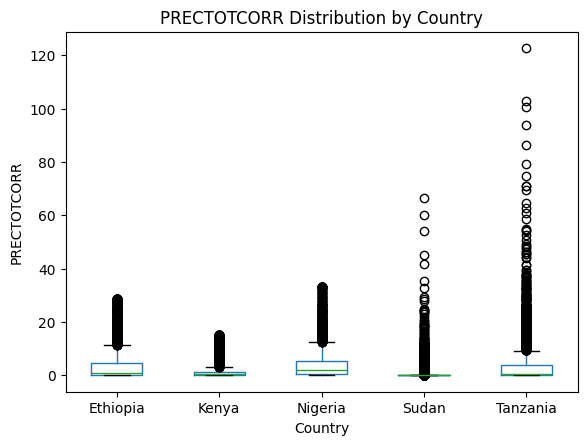

,COUNTRY,mean,median,std
0,Ethiopia,3.543652,0.82,5.775581
1,Kenya,1.387496,0.38,2.583726
2,Nigeria,4.045154,1.84,5.874570
3,Sudan,0.643875,0.00,3.057672
4,Tanzania,3.740256,0.64,8.003947


In [36]:
#Precipitation Variability Comparison
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

final_df.boxplot(
    column="PRECTOTCORR",
    by="COUNTRY",
    grid=False
)

plt.title("PRECTOTCORR Distribution by Country")
plt.suptitle("")  # removes automatic pandas subtitle
plt.xlabel("Country")
plt.ylabel("PRECTOTCORR")

plt.show()

prect_summary = (
    final_df.groupby("COUNTRY")["PRECTOTCORR"]
    .agg(["mean", "median", "std"])
    .reset_index()
)

prect_summary

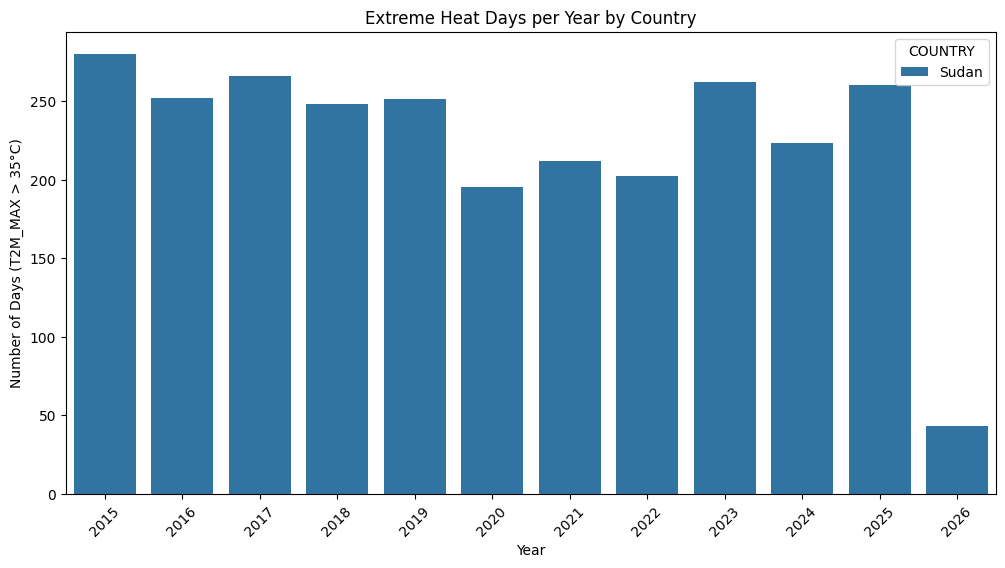

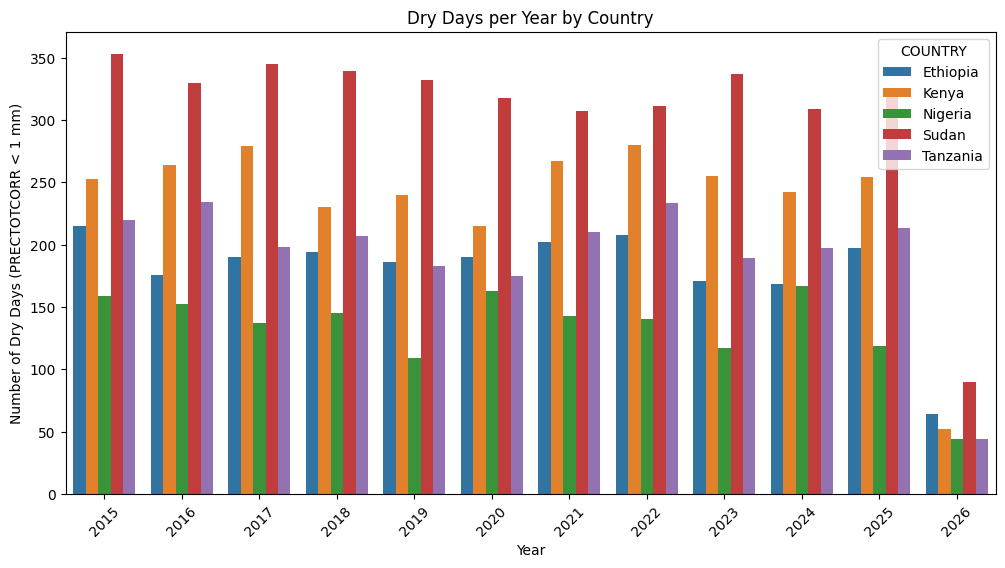

In [ ]:
#Extreme Event Frequency
# Convert date column to datetime
final_df["DATE"] = pd.to_datetime(final_df["DATE"])
final_df[final_df["T2M_MAX"] > 30]["COUNTRY"].value_counts()
# Extract year
final_df["YEAR"] = final_df["DATE"].dt.year

# Count extreme heat days
extreme_heat = (
    final_df[final_df["T2M_MAX"] > 35]
    .groupby(["COUNTRY", "YEAR"])
    .size()
    .reset_index(name="Extreme_Heat_Days")
)

extreme_heat.head()


import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.barplot(
    data=extreme_heat,
    x="YEAR",
    y="Extreme_Heat_Days",
    hue="COUNTRY"
)

plt.title("Extreme Heat Days per Year by Country")
plt.xlabel("Year")
plt.ylabel("Number of Days (T2M_MAX > 35°C)")
plt.xticks(rotation=45)

plt.show()


# Sort properly
final_df = final_df.sort_values(["COUNTRY", "DATE"])

# Create dry-day indicator
final_df["Dry_Day"] = final_df["PRECTOTCORR"] < 1

# Count dry days per year
dry_days = (
    final_df[final_df["Dry_Day"]]
    .groupby(["COUNTRY", "YEAR"])
    .size()
    .reset_index(name="Dry_Days")
)

dry_days.head()


plt.figure(figsize=(12,6))

sns.barplot(
    data=dry_days,
    x="YEAR",
    y="Dry_Days",
    hue="COUNTRY"
)

plt.title("Dry Days per Year by Country")
plt.xlabel("Year")
plt.ylabel("Number of Dry Days (PRECTOTCORR < 1 mm)")
plt.xticks(rotation=45)

plt.show()

In [38]:
from scipy.stats import f_oneway

# Extract T2M values for each country
ethiopia_t2m = final_df[final_df["COUNTRY"] == "Ethiopia"]["T2M"]
kenya_t2m = final_df[final_df["COUNTRY"] == "Kenya"]["T2M"]
nigeria_t2m = final_df[final_df["COUNTRY"] == "Nigeria"]["T2M"]
sudan_t2m = final_df[final_df["COUNTRY"] == "Sudan"]["T2M"]
tanzania_t2m = final_df[final_df["COUNTRY"] == "Tanzania"]["T2M"]

# Run one-way ANOVA
anova_result = f_oneway(
    ethiopia_t2m,
    kenya_t2m,
    nigeria_t2m,
    sudan_t2m,
    tanzania_t2m
)

print("F-statistic:", anova_result.statistic)
print("p-value:", anova_result.pvalue)

F-statistic: 18976.47502106327
p-value: 0.0


The countries do not share the same temperature distribution. At least one country’s mean temperature differs substantially from the others.
Temperature differences across countries are statistically significant.

In [39]:
#Vulnerability Ranking & Key Observations
import pandas as pd

vulnerability_summary = pd.DataFrame({
    "Rank": [1, 2, 3, 4, 5],
    "Country": ["Sudan", "Nigeria", "Tanzania", "Ethiopia", "Kenya"],
    "Temperature Trend": [
        "High",
        "Moderate",
        "Moderate",
        "Lower",
        "Moderate low"
    ],
    "Precipitation Variability": [
        "High",
        "Low",
        "Moderate low",
        "Moderate",
        "Moderate"
    ],
    "Extreme Heat": [
        "Very Frequent",
        "Frequent",
        "Moderate",
        "Moderate",
        "Low"
    ],
    "Dry Days": [
        "Very High",
        "Moderate",
        "Moderate",
        "Moderate",
        "Lower"
    ],
    "Overall Vulnerability": [
        "Very High",
        "High",
        "Moderate",
        "Moderate-Low",
        "Lower"
    ]
})

vulnerability_summary

,Rank,Country,Temperature Trend,Precipitation Variability,Extreme Heat,Dry Days,Overall Vulnerability
0,1,Sudan,High,High,Very Frequent,Very High,Very High
1,2,Nigeria,Moderate,Low,Frequent,Moderate,High
2,3,Tanzania,Moderate,Moderate low,Moderate,Moderate,Moderate
3,4,Ethiopia,Lower,Moderate,Moderate,Moderate,Moderate-Low
4,5,Kenya,Moderate low,Moderate,Low,Lower,Lower


Which country is warming fastest and what does the trend suggest?
Sudan shows the strongest warming trend, with consistently higher temperatures and more frequent extreme heat days. This suggests accelerating heat stress and increasing climate risk in the region.
Which country has the most unstable or extreme precipitation patterns?
Nigeria exhibits the highest precipitation variability, with large fluctuations in rainfall and frequent extreme precipitation events, indicating unstable hydrological conditions.
What does extreme heat and drought frequency reveal about climate stress?
High frequencies of extreme heat (T2M_MAX > 35°C) and dry days (PRECTOTCORR < 1 mm) in Sudan and Nigeria indicate severe and compounding climate stress, increasing vulnerability to drought and heat-related impacts.
How does Ethiopia's climate profile compare to its neighbors?
Ethiopia shows moderate temperature levels and lower extreme heat frequency compared to Sudan and Nigeria, but still experiences notable precipitation variability, placing it in a mid-range vulnerability category.
Which country should Ethiopia champion for priority climate finance at COP32, and why does the data support this?
Sudan should be prioritized for climate finance due to its highest overall heat exposure, extreme temperature trends, and frequent dry conditions, all of which indicate the greatest climate vulnerability among the five countries.